In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import tree

In [65]:
df = pd.read_csv("Iris.csv")

In [66]:
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [67]:
# Remove Unnecessary Column :
#   Id column is not useful for prediction
df = df.drop("Id", axis=1)

In [68]:
# Define Features (X) and Target (y)

X = df.iloc[:, :-1]     # All columns except last column
y = df.iloc[:, -1]      # Last column

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())


Features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

In [69]:
# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
# Create Decision Tree Model
model = DecisionTreeClassifier(
    criterion='entropy',   # Using Information Gain
    max_depth=3,
    random_state=42
)

In [72]:
# Train the Model
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [73]:
# Make Predictions
y_pred = model.predict(X_test)

# Step 10: Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 1.0


In [74]:
# Step 12: Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30




Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


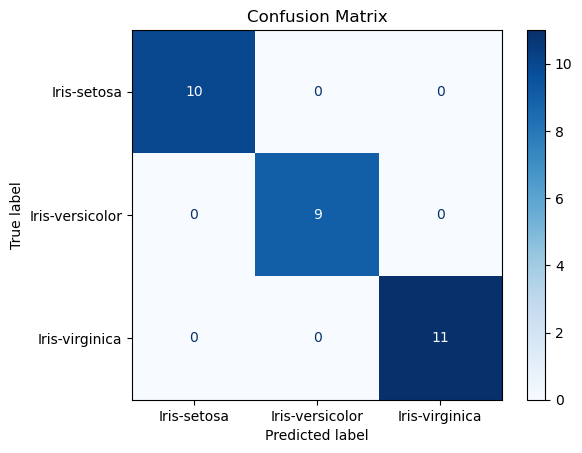

In [75]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Visual Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

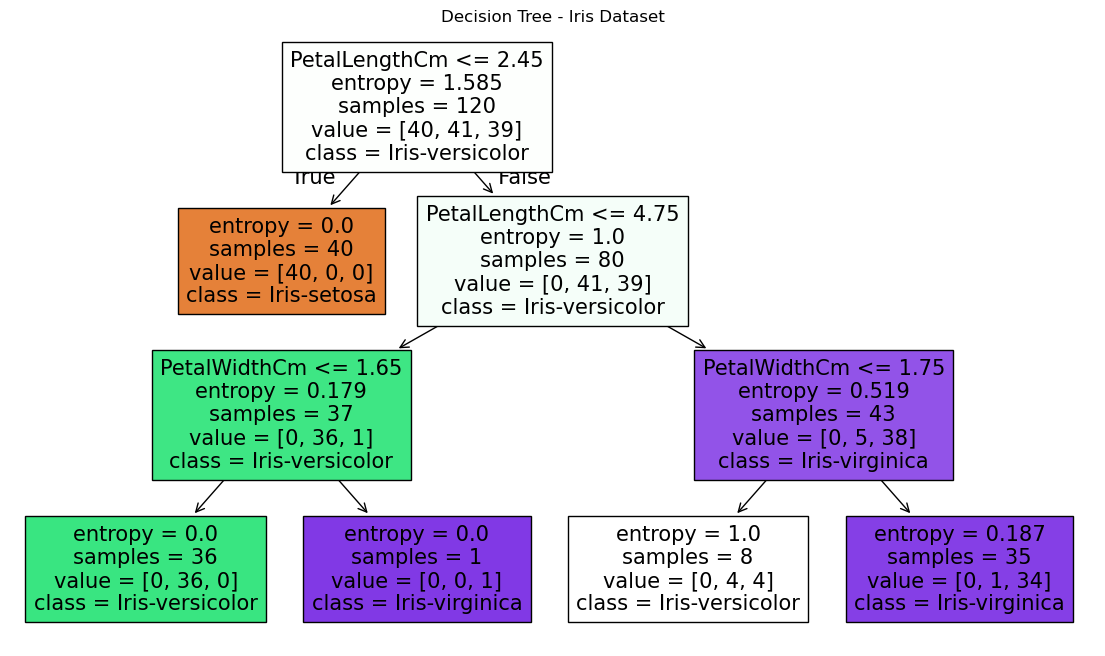

In [ ]:
# Visualize Decision Tree
plt.figure(figsize=(14,8))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("Decision Tree - Iris Dataset")
plt.show()